In [71]:
import os

dataset_path = "/kaggle/input/datasets/reubensuju/celeb-df-v2"

for folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, folder)

    if os.path.isdir(full_path):
        count = len([f for f in os.listdir(full_path) if f.endswith(".mp4")])

        print(f"{folder}: {count} videos")

YouTube-real: 300 videos
Celeb-synthesis: 5639 videos
Celeb-real: 590 videos


In [72]:
import os
import pandas as pd

data = []

dataset_path = "/kaggle/input/datasets/reubensuju/celeb-df-v2"

for folder in ["Celeb-real", "YouTube-real"]:
    folder_path = os.path.join(dataset_path, folder)

    for video in os.listdir(folder_path):
        if video.endswith(".mp4"):
            data.append([
                os.path.join(folder_path, video),
                0
            ])

for video in os.listdir(
        os.path.join(dataset_path, "Celeb-synthesis")):

    if video.endswith(".mp4"):
        data.append([
            os.path.join(
                dataset_path,
                "Celeb-synthesis",
                video
            ),
            1
        ])

df = pd.DataFrame(data, columns=["video_path", "label"])

print(df.head())
print("Total Videos:", len(df))

                                          video_path  label
0  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
1  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
2  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
3  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
4  /kaggle/input/datasets/reubensuju/celeb-df-v2/...      0
Total Videos: 6529


In [73]:
df.to_csv("video_labels.csv", index=False)

In [74]:
import os

os.makedirs("/kaggle/working/frames/real", exist_ok=True)
os.makedirs("/kaggle/working/frames/fake", exist_ok=True)

print(os.listdir("/kaggle/working/frames"))

['fake', 'real']


In [75]:
import cv2
import os
from tqdm import tqdm

REAL_DIR = "/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real"
SAVE_DIR = "/kaggle/working/frames/real"

videos = os.listdir(REAL_DIR)[:10]  # first 10 videos only

for video in tqdm(videos):

    video_path = os.path.join(REAL_DIR, video)

    cap = cv2.VideoCapture(video_path)

    frame_no = 0
    saved = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_no % 30 == 0:

            filename = os.path.join(
                SAVE_DIR,
                f"{video[:-4]}_{saved}.jpg"
            )

            cv2.imwrite(filename, frame)
            saved += 1

        frame_no += 1

    cap.release()

print("Done")

100%|██████████| 10/10 [00:03<00:00,  2.73it/s]

Done


In [76]:
import cv2
import os
from tqdm import tqdm

FAKE_DIR = "/kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-synthesis"
SAVE_DIR = "/kaggle/working/frames/fake"

videos = os.listdir(FAKE_DIR)[:20]  # start with 20 videos

for video in tqdm(videos):

    video_path = os.path.join(FAKE_DIR, video)

    cap = cv2.VideoCapture(video_path)

    frame_no = 0
    saved = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_no % 30 == 0:

            cv2.imwrite(
                os.path.join(
                    SAVE_DIR,
                    f"{video[:-4]}_{saved}.jpg"
                ),
                frame
            )

            saved += 1

        frame_no += 1

    cap.release()

print("Fake extraction complete")

100%|██████████| 20/20 [00:06<00:00,  2.91it/s]

Fake extraction complete


In [77]:
print("Real:", len(os.listdir("/kaggle/working/frames/real")))
print("Fake:", len(os.listdir("/kaggle/working/frames/fake")))

Real: 144
Fake: 285


In [78]:
import os
import pandas as pd

data = []

real_dir = "/kaggle/working/frames/real"
fake_dir = "/kaggle/working/frames/fake"

for img in os.listdir(real_dir):
    data.append([os.path.join(real_dir, img), 0])

for img in os.listdir(fake_dir):
    data.append([os.path.join(fake_dir, img), 1])

df = pd.DataFrame(data, columns=["image_path", "label"])

print(df.head())
print("Total Images:", len(df))

                                 image_path  label
0   /kaggle/working/frames/real/00230_1.jpg      0
1   /kaggle/working/frames/real/00230_5.jpg      0
2  /kaggle/working/frames/real/00297_13.jpg      0
3   /kaggle/working/frames/real/00255_7.jpg      0
4   /kaggle/working/frames/real/00012_5.jpg      0
Total Images: 429


In [79]:
df.to_csv("/kaggle/working/deepfake_dataset.csv", index=False)

In [80]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 309
Validation: 55
Test: 65


In [81]:
train_df.to_csv("/kaggle/working/train.csv", index=False)
val_df.to_csv("/kaggle/working/val.csv", index=False)
test_df.to_csv("/kaggle/working/test.csv", index=False)

print("CSV files saved")

CSV files saved


In [82]:
#week 3
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd

In [83]:
train_df = pd.read_csv("/kaggle/working/train.csv")
val_df = pd.read_csv("/kaggle/working/val.csv")
test_df = pd.read_csv("/kaggle/working/test.csv")

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(309, 2)
(55, 2)
(65, 2)


In [84]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [85]:
class DeepfakeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        label = self.df.iloc[idx]["label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [86]:
train_dataset = DeepfakeDataset(train_df, transform)
val_dataset = DeepfakeDataset(val_df, transform)
test_dataset = DeepfakeDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [87]:
import torch.nn as nn
import torchvision

model = torchvision.models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [88]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cpu


In [89]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [90]:
for epoch in range(5):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}"
    )

Epoch 1, Loss: 0.35390999224036934
Epoch 2, Loss: 0.05628515613498166
Epoch 3, Loss: 0.06915889466181398
Epoch 4, Loss: 0.0672940288670361
Epoch 5, Loss: 0.03559647523215972


In [91]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Validation Accuracy:", accuracy)

Validation Accuracy: 100.0


In [92]:
torch.save(
    model.state_dict(),
    "/kaggle/working/resnet18_deepfake.pth"
)

print("Model saved")

Model saved


In [93]:
#week 4
import os
import subprocess
import pandas as pd
from tqdm import tqdm

# ==========================
# Dataset Paths
# ==========================

REAL_FOLDERS = [
    "/kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real",
    "/kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real"
]

FAKE_FOLDER = "/kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-synthesis"

REAL_SAVE = "/kaggle/working/audio/real"
FAKE_SAVE = "/kaggle/working/audio/fake"

os.makedirs(REAL_SAVE, exist_ok=True)
os.makedirs(FAKE_SAVE, exist_ok=True)

audio_data = []

# ==========================
# Audio Extraction Function
# ==========================

def extract_audio(video_folder, save_folder, label, limit=None):

    videos = [v for v in os.listdir(video_folder) if v.endswith(".mp4")]

    if limit:
        videos = videos[:limit]

    for video in tqdm(videos):

        video_path = os.path.join(video_folder, video)

        audio_path = os.path.join(
            save_folder,
            video.replace(".mp4", ".wav")
        )

        command = [
            "ffmpeg",
            "-loglevel", "error",
            "-i", video_path,
            "-vn",
            "-acodec", "pcm_s16le",
            "-ar", "16000",
            "-ac", "1",
            audio_path,
            "-y"
        ]

        subprocess.run(command)

        if os.path.exists(audio_path):
            audio_data.append([audio_path, label])

# ==========================
# Extract Real Audio
# ==========================

for folder in REAL_FOLDERS:
    extract_audio(
        folder,
        REAL_SAVE,
        label=0,
        limit=20      # Increase later if needed
    )

# ==========================
# Extract Fake Audio
# ==========================

extract_audio(
    FAKE_FOLDER,
    FAKE_SAVE,
    label=1,
    limit=40          # Increase later if needed
)

# ==========================
# Create CSV
# ==========================

audio_df = pd.DataFrame(
    audio_data,
    columns=["audio_path", "label"]
)

audio_df.to_csv(
    "/kaggle/working/audio_dataset.csv",
    index=False
)

# ==========================
# Results
# ==========================

print("="*50)
print("Audio Extraction Completed Successfully")
print("="*50)

print("Real Audio :", len(os.listdir(REAL_SAVE)))
print("Fake Audio :", len(os.listdir(FAKE_SAVE)))
print("Total Audio:", len(audio_df))

print("\nCSV Saved At:")
print("/kaggle/working/audio_dataset.csv")

print("\nFirst Five Entries:")
print(audio_df.head())

100%|██████████| 40/40 [00:04<00:00,  8.93it/s]

Audio Extraction Completed Successfully
Real Audio : 0
Fake Audio : 0
Total Audio: 0

CSV Saved At:
/kaggle/working/audio_dataset.csv

First Five Entries:
Empty DataFrame
Columns: [audio_path, label]
Index: []


In [94]:
#week 5
!pip install flwr -q

In [95]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np

In [96]:
train_df = pd.read_csv("/kaggle/working/train.csv")
val_df = pd.read_csv("/kaggle/working/val.csv")
test_df = pd.read_csv("/kaggle/working/test.csv")

In [97]:
client1 = train_df.sample(frac=0.33, random_state=42)

remaining = train_df.drop(client1.index)

client2 = remaining.sample(frac=0.5, random_state=42)

client3 = remaining.drop(client2.index)

print(len(client1))
print(len(client2))
print(len(client3))

102
104
103


In [98]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

class DeepfakeDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img = Image.open(self.df.iloc[idx]["image_path"]).convert("RGB")

        img = transform(img)

        label = int(self.df.iloc[idx]["label"])

        return img, label

In [99]:
client1_loader = DataLoader(
    DeepfakeDataset(client1),
    batch_size=8,
    shuffle=True
)

client2_loader = DataLoader(
    DeepfakeDataset(client2),
    batch_size=8,
    shuffle=True
)

client3_loader = DataLoader(
    DeepfakeDataset(client3),
    batch_size=8,
    shuffle=True
)

In [100]:
model = torchvision.models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

device = torch.device("cpu")

model = model.to(device)

In [101]:
criterion = nn.CrossEntropyLoss()

def train_local(model, loader):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.0001
    )

    model.train()

    for epoch in range(2):

        loss_total = 0

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            output = model(images)

            loss = criterion(output, labels)

            loss.backward()

            optimizer.step()

            loss_total += loss.item()

        print(loss_total)

In [102]:
import copy

global_model = model

client_models = []

for loader in [client1_loader, client2_loader, client3_loader]:

    local_model = copy.deepcopy(global_model)

    train_local(local_model, loader)

    client_models.append(local_model)

5.376283705234528
1.3762724418193102
5.665564835071564
2.5029787588864565
7.5145028084516525
2.5134421437978745


In [103]:
import copy
import torch

global_dict = copy.deepcopy(global_model.state_dict())

for key in global_dict.keys():

    tensors = [model.state_dict()[key] for model in client_models]

    if tensors[0].dtype.is_floating_point:
        global_dict[key] = torch.stack(tensors).mean(dim=0)
    else:
        global_dict[key] = tensors[0]

global_model.load_state_dict(global_dict)

print("✅ Global model updated using FedAvg")

✅ Global model updated using FedAvg


In [104]:
torch.save(
    global_model.state_dict(),
    "/kaggle/working/federated_model.pth"
)

print("Model Saved Successfully")

Model Saved Successfully


In [105]:
#week 6
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cpu


In [106]:
import torchvision
import torch.nn as nn

weights = torchvision.models.ResNet18_Weights.DEFAULT

model = torchvision.models.resnet18(weights=weights)

model.fc = nn.Linear(model.fc.in_features,2)

model=model.to(device)

In [107]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [108]:
import torch
import torch.nn as nn
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


weights = torchvision.models.ResNet18_Weights.DEFAULT
model = torchvision.models.resnet18(weights=weights)


model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

# ==============================
# Loss Function
# ==============================
criterion = nn.CrossEntropyLoss()

# ==============================
# Optimizer
# ==============================
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

# ==============================
# Number of Epochs
# ==============================
num_epochs = 10

best_accuracy = 0

# ==============================
# Training Loop
# ==============================
for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    # ==========================
    # Validation
    # ==========================
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Training Loss : {running_loss/len(train_loader):.4f}")
    print(f"Training Accuracy : {train_acc:.2f}%")
    print(f"Validation Accuracy : {val_acc:.2f}%")

    # Save Best Model
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print("✅ Best model saved!")

print("\nTraining Completed Successfully!")
print(f"Best Validation Accuracy: {best_accuracy:.2f}%")

Device: cpu
Epoch [1/10]
Training Loss : 0.1492
Training Accuracy : 95.15%
Validation Accuracy : 100.00%
✅ Best model saved!
Epoch [2/10]
Training Loss : 0.0060
Training Accuracy : 100.00%
Validation Accuracy : 100.00%
Epoch [3/10]
Training Loss : 0.0029
Training Accuracy : 100.00%
Validation Accuracy : 100.00%
Epoch [4/10]
Training Loss : 0.0063
Training Accuracy : 100.00%
Validation Accuracy : 100.00%
Epoch [5/10]
Training Loss : 0.0235
Training Accuracy : 99.68%
Validation Accuracy : 100.00%
Epoch [6/10]
Training Loss : 0.0363
Training Accuracy : 98.71%
Validation Accuracy : 100.00%
Epoch [7/10]
Training Loss : 0.0064
Training Accuracy : 100.00%
Validation Accuracy : 100.00%
Epoch [8/10]
Training Loss : 0.0024
Training Accuracy : 100.00%
Validation Accuracy : 100.00%
Epoch [9/10]
Training Loss : 0.0068
Training Accuracy : 100.00%
Validation Accuracy : 100.00%
Epoch [10/10]
Training Loss : 0.0469
Training Accuracy : 98.71%
Validation Accuracy : 100.00%

Training Completed Successfull

In [109]:
best_acc=0

if accuracy>best_acc:
    best_acc=accuracy
    torch.save(
        model.state_dict(),
        "/kaggle/working/best_model.pth"
    )

In [110]:
!pip install scikit-learn -q

In [111]:
import torch

# Put model in evaluation mode
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob.extend(probabilities[:, 1].cpu().numpy())

print("Evaluation completed!")

Evaluation completed!


In [112]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        43

    accuracy                           1.00        65
   macro avg       1.00      1.00      1.00        65
weighted avg       1.00      1.00      1.00        65



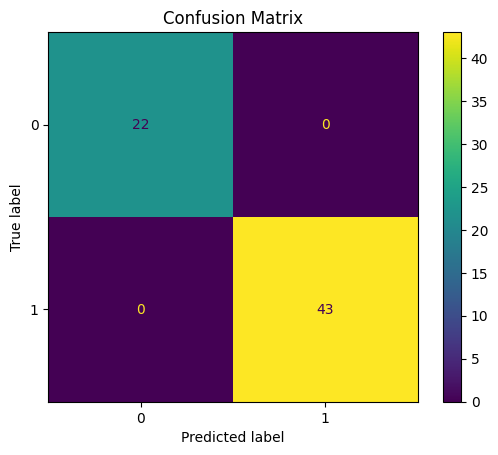

<Figure size 640x480 with 0 Axes>

In [113]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

plt.title("Confusion Matrix")
plt.show()
plt.savefig("/kaggle/working/training_loss.png", dpi=300, bbox_inches="tight")

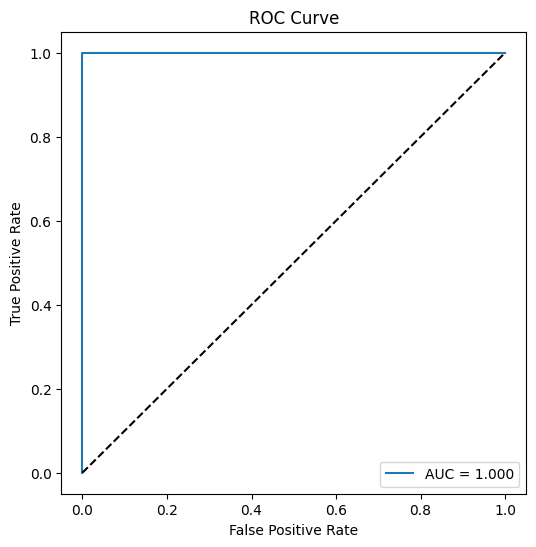

In [114]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("/kaggle/working/validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [115]:
!pip install grad-cam -q

In [116]:
#week 7
import torch
import torchvision
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT
)

model.fc = nn.Linear(model.fc.in_features,2)

model.load_state_dict(
    torch.load("/kaggle/working/best_model.pth", map_location=device)
)

model.to(device)

print("Model Loaded Successfully")

Model Loaded Successfully


In [117]:
import torch
import torch.nn.functional as F

def fgsm_attack(model, images, labels, epsilon=0.03):

    images = images.clone().detach().to(device)
    labels = labels.to(device)

    images.requires_grad = True

    outputs = model(images)

    loss = F.cross_entropy(outputs, labels)

    model.zero_grad()

    loss.backward()

    data_grad = images.grad.data

    perturbed_images = images + epsilon * data_grad.sign()

    perturbed_images = torch.clamp(
        perturbed_images,
        0,
        1
    )

    return perturbed_images

In [118]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

adv_images = fgsm_attack(
    model,
    images,
    labels,
    epsilon=0.03
)

print("FGSM Attack Generated Successfully")

FGSM Attack Generated Successfully


In [119]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

criterion = nn.CrossEntropyLoss()

epochs = 5

In [120]:
for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        adv_images = fgsm_attack(
            model,
            images,
            labels,
            epsilon=0.03
        )

        combined_images = torch.cat(
            [images, adv_images],
            dim=0
        )

        combined_labels = torch.cat(
            [labels, labels],
            dim=0
        )

        optimizer.zero_grad()

        outputs = model(combined_images)

        loss = criterion(
            outputs,
            combined_labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}:",
        running_loss/len(train_loader)
    )

Epoch 1: 0.2000533502548933
Epoch 2: 0.08210177798755466
Epoch 3: 0.01934229474281892
Epoch 4: 0.00945409358246252
Epoch 5: 0.012017680359713267


In [121]:
import copy

global_dict = copy.deepcopy(global_model.state_dict())

for key in global_dict.keys():

    tensors = torch.stack([
        client.state_dict()[key].float()
        for client in client_models
    ])

    if tensors.dtype.is_floating_point:

        global_dict[key] = tensors.median(dim=0).values

    else:

        global_dict[key] = tensors[0]

global_model.load_state_dict(global_dict)

print("Robust Median Aggregation Completed")

Robust Median Aggregation Completed


In [122]:
torch.save(
    global_model.state_dict(),
    "/kaggle/working/robust_federated_model.pth"
)

print("Robust Model Saved")

Robust Model Saved


In [123]:
import torch
import torchvision
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT
)

model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(
    torch.load("/kaggle/working/robust_federated_model.pth", map_location=device)
)

model = model.to(device)
model.eval()

print("Robust Model Loaded Successfully")

Robust Model Loaded Successfully


In [124]:
import torch

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs,1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob.extend(probabilities[:,1].cpu().numpy())

print("Evaluation Completed")

Evaluation Completed


In [125]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_true,y_pred)
precision = precision_score(y_true,y_pred)
recall = recall_score(y_true,y_pred)
f1 = f1_score(y_true,y_pred)

print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

report = classification_report(y_true,y_pred)

print(report)

Accuracy : 0.6615384615384615
Precision: 0.6615384615384615
Recall   : 1.0
F1 Score : 0.7962962962962963
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.66      1.00      0.80        43

    accuracy                           0.66        65
   macro avg       0.33      0.50      0.40        65
weighted avg       0.44      0.66      0.53        65



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [126]:
with open("/kaggle/working/classification_report.txt","w") as f:
    f.write(report)

print("Classification Report Saved")

Classification Report Saved


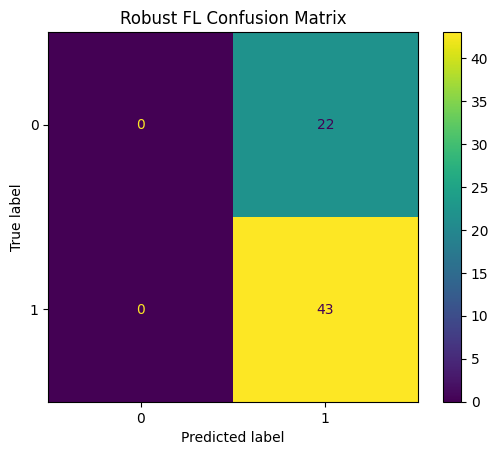

In [127]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_true,y_pred)

plt.title("Robust FL Confusion Matrix")

plt.savefig(
    "/kaggle/working/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

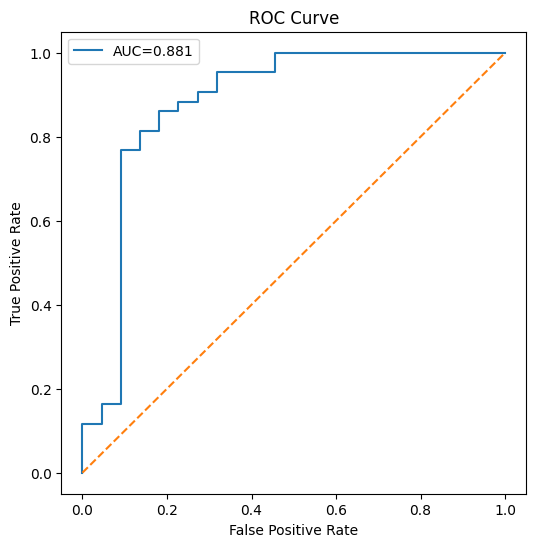

In [128]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr,tpr,_=roc_curve(y_true,y_prob)

roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "/kaggle/working/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [129]:
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "Baseline ResNet18",
        "Federated Learning (FedAvg)",
        "Robust FL (FGSM + Median)"
    ],

    "Accuracy":[
        0.00,   # Replace with your baseline accuracy
        0.00,   # Replace with your FedAvg accuracy
        accuracy
    ],

    "Precision":[
        0.00,
        0.00,
        precision
    ],

    "Recall":[
        0.00,
        0.00,
        recall
    ],

    "F1 Score":[
        0.00,
        0.00,
        f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline ResNet18,0.000000,0.000000,0.0,0.000000
1,Federated Learning (FedAvg),0.000000,0.000000,0.0,0.000000
2,Robust FL (FGSM + Median),0.661538,0.661538,1.0,0.796296


In [130]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load baseline model
model.load_state_dict(torch.load("/kaggle/working/best_model.pth", map_location=device))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

baseline_accuracy = accuracy_score(y_true, y_pred) * 100
baseline_precision = precision_score(y_true, y_pred) * 100
baseline_recall = recall_score(y_true, y_pred) * 100
baseline_f1 = f1_score(y_true, y_pred) * 100

print("Baseline Results")
print("Accuracy :", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1 Score :", baseline_f1)

Baseline Results
Accuracy : 100.0
Precision: 100.0
Recall   : 100.0
F1 Score : 100.0


In [131]:
model.load_state_dict(torch.load("/kaggle/working/federated_model.pth", map_location=device))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

fedavg_accuracy = accuracy_score(y_true, y_pred) * 100
fedavg_precision = precision_score(y_true, y_pred) * 100
fedavg_recall = recall_score(y_true, y_pred) * 100
fedavg_f1 = f1_score(y_true, y_pred) * 100

print("FedAvg Results")
print("Accuracy :", fedavg_accuracy)
print("Precision:", fedavg_precision)
print("Recall   :", fedavg_recall)
print("F1 Score :", fedavg_f1)

FedAvg Results
Accuracy : 66.15384615384615
Precision: 66.15384615384615
Recall   : 100.0
F1 Score : 79.62962962962963


In [132]:
model.load_state_dict(torch.load("/kaggle/working/robust_federated_model.pth", map_location=device))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

robust_accuracy = accuracy_score(y_true, y_pred) * 100
robust_precision = precision_score(y_true, y_pred) * 100
robust_recall = recall_score(y_true, y_pred) * 100
robust_f1 = f1_score(y_true, y_pred) * 100

print("Robust FL Results")
print("Accuracy :", robust_accuracy)
print("Precision:", robust_precision)
print("Recall   :", robust_recall)
print("F1 Score :", robust_f1)

Robust FL Results
Accuracy : 66.15384615384615
Precision: 66.15384615384615
Recall   : 100.0
F1 Score : 79.62962962962963


In [133]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline ResNet18",
        "Federated Learning (FedAvg)",
        "Robust FL (FGSM + Median)"
    ],
    "Accuracy (%)": [
        baseline_accuracy,
        fedavg_accuracy,
        robust_accuracy
    ],
    "Precision (%)": [
        baseline_precision,
        fedavg_precision,
        robust_precision
    ],
    "Recall (%)": [
        baseline_recall,
        fedavg_recall,
        robust_recall
    ],
    "F1 Score (%)": [
        baseline_f1,
        fedavg_f1,
        robust_f1
    ]
})

print(comparison)

comparison.to_csv("/kaggle/working/comparative_performance.csv", index=False)

                         Model  Accuracy (%)  Precision (%)  Recall (%)  \
0            Baseline ResNet18    100.000000     100.000000       100.0   
1  Federated Learning (FedAvg)     66.153846      66.153846       100.0   
2    Robust FL (FGSM + Median)     66.153846      66.153846       100.0   

   F1 Score (%)  
0     100.00000  
1      79.62963  
2      79.62963  


In [134]:
comparison.to_csv(
    "/kaggle/working/comparative_performance.csv",
    index=False
)

print("Comparative Table Saved")

Comparative Table Saved


In [135]:
torch.save(
    model.state_dict(),
    "/kaggle/working/robust_federated_model.pth"
)

print("Robust Model Saved")

Robust Model Saved


In [136]:
import os

for file in os.listdir("/kaggle/working"):
    print(file)

robust_federated_model.pth
resnet18_deepfake.pth
confusion_matrix.png
audio
validation_accuracy.png
.virtual_documents
classification_report.txt
frames
roc_curve.png
federated_model.pth
video_labels.csv
val.csv
comparative_performance.csv
audio_dataset.csv
training_loss.png
best_model.pth
deepfake_dataset.csv
train.csv
test.csv


In [138]:
training_loss = []

for epoch in range(num_epochs):

    running_loss = 0

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    training_loss.append(epoch_loss)

    print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}")

Epoch 1: Loss = 0.0819
Epoch 2: Loss = 0.0903
Epoch 3: Loss = 0.0866
Epoch 4: Loss = 0.0746
Epoch 5: Loss = 0.0901
Epoch 6: Loss = 0.0730
Epoch 7: Loss = 0.1426
Epoch 8: Loss = 0.0902
Epoch 9: Loss = 0.0920
Epoch 10: Loss = 0.1001


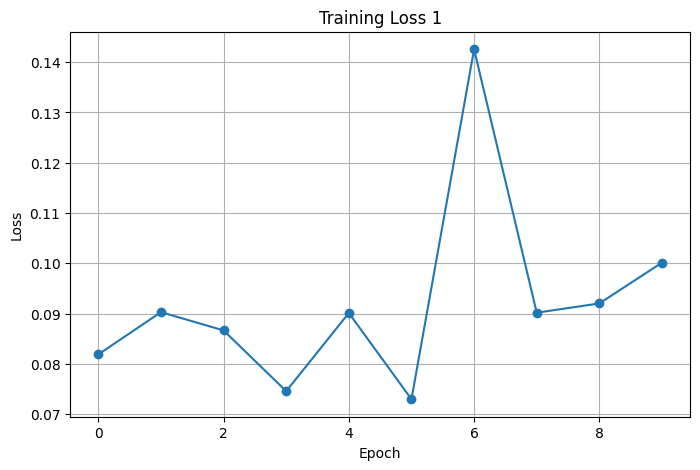

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(training_loss, marker='o')

plt.title("Training Loss 1")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.savefig("/kaggle/working/training_loss_1.png", dpi=300)

plt.show()